In [1]:
from encord import EncordUserClient
import os
user_client = EncordUserClient.create_with_ssh_private_key(ssh_private_key_path = os.environ.get('ENCORD_SSH_KEY_FILE'))

In [2]:
project = user_client.get_project("7b866df5-9eb7-4b76-b712-9e0f95ee2449")

In [3]:
lr = project.list_label_rows_v2(data_title_eq='storage-new-folder.png')[0]

In [4]:
lr.initialise_labels()

In [5]:
clsi = lr.get_classification_instances()

In [10]:
cls_1 = clsi[0]

In [11]:
for ans in cls_1.get_all_static_answers():
    print(ans)
    print(ans.to_encord_dict())

RadioAnswer(NestableOption(feature_node_hash='5qvmjZEN', uid=[1, 1, 1], label='QA Pair', value='QA_Pair', nested_options=[TextAttribute(feature_node_hash='L27fSN3D', uid=[1, 1, 1, 1]), TextAttribute(feature_node_hash='4mvdzZ+c', uid=[1, 1, 1, 2])]))
{'name': 'Question Answer Pair 1', 'value': 'question_answer_pair_1', 'answers': [{'name': 'QA Pair', 'value': 'QA_Pair', 'featureHash': '5qvmjZEN'}], 'featureHash': 'D9oJlIXz', 'manualAnnotation': True}
TextAnswer(How can I create a new folder in the Encord platform?)
{'name': 'Question', 'value': 'question', 'answers': 'How can I create a new folder in the Encord platform?', 'featureHash': 'L27fSN3D', 'manualAnnotation': True}
TextAnswer(Navigate to the Files section of Index, then click '+ New folder'. A dialog will appear where you can give the folder a meaningful name and description. Finally, click 'Create' to create the folder.)
{'name': 'Answer', 'value': 'answer', 'answers': "Navigate to the Files section of Index, then click '+ Ne

In [2]:
import pandas as pd

In [9]:
qa_df = pd.read_csv('qa_results_2.csv')

In [10]:
og_df = pd.read_csv('raw_multimodal_data.csv')

In [4]:
og_df = og_df.reset_index()

In [11]:
og_df.columns

Index(['Unnamed: 0', 'index', 'image url', 'above text', 'below text',
       'source markdown file'],
      dtype='object')

In [12]:
og_df = og_df[[og_df.columns[1],og_df.columns[2]]]

In [14]:
comb_df = pd.merge(left = og_df,right=qa_df,left_on=og_df.columns[0],right_on='index')

In [16]:
comb_df.to_csv('train_data_4.csv')

In [15]:
comb_df

,index,image url,Unnamed: 0,Question 1,Answer 1,Question 2,Answer 2,Question 3,Answer 3
0,0,https://storage.googleapis.com/docs-media.enco...,41,What option should I choose to deploy a Lambda...,You should select the 'Container image' option...,How can I begin creating a Lambda function fro...,"According to the screenshot, you can choose ei...",What do I do next to use a container image for...,"Next, after selecting 'Container image', you n..."
1,1,https://storage.googleapis.com/docs-media.enco...,152,What type of model is being created in this in...,The model being created is an 'Object detectio...,Which framework is selected for this model?,The selected framework for the model is 'PYTOR...,What do I do next to finalize the creation of ...,To finalize the creation of the apple detectio...
2,2,https://storage.googleapis.com/docs-media.enco...,248,How do I start automated labeling in this inte...,"To start automated labeling, click the 'Automa...",Where can I find the classification options fo...,The classification options are located on the ...,What do I do next to work with detection and s...,"To proceed with detection and segmentation, op..."
3,3,https://storage.googleapis.com/docs-media.enco...,265,How can I select a different model to run in t...,You can select a different model by clicking o...,What should I do next to start the detection p...,"To start the detection process, make sure you ...",How can I set the confidence level for the det...,You can set the confidence level by adjusting ...
4,4,https://storage.googleapis.com/docs-media.enco...,3,What model type should I select for a day/nigh...,You should select the 'Classification' model t...,How can I add more categories to the model's o...,Click on the '+ Add model ontology' button in ...,What do I do next to finalize creating my clas...,"Answer To finalize creating your model, click ..."
...,...,...,...,...,...,...,...,...,...
574,725,https://storage.googleapis.com/docs-media.enco...,57,Why is Frame i flagged in the screenshot?,Frame i is flagged because it does not include...,What information is missing in Frame i compare...,"Frame i is missing the object labeled 'CAT', w...",What do I do next to identify more missing obj...,"To identify more missing objects, use the runn..."
575,728,https://storage.googleapis.com/docs-media.enco...,141,"What does the formula for Score(o_i,t) imply a...",The formula suggests that the score for an obj...,"According to the formula, when would the score...",The score would be zero if the class of the ob...,What do I do next to evaluate the consistency ...,"Next, you should apply this formula to the obj..."
576,737,https://storage.googleapis.com/docs-media.enco...,170,Which options can I select from in the 'Order ...,"You can select from 'Data', 'Labels', and 'Pre...",What are the next steps after using filters on...,"After using filters on the embedding plot, you...",How many frames are currently displayed in the...,"The plot displays 3K frames, and the identifie..."
577,744,https://storage.googleapis.com/docs-media.enco...,44,How can I sync my project data to Active?,"To sync your project data to Active, mouseover...",What do I do next to view the Annotate comment...,After you click the 'Sync Project Data' option...,Where can I find the option to import a new An...,You can find the option to import a new Annota...


In [41]:
train_loss = pd.read_csv('/Users/felixcohen/Documents/training_loss_attempt_2.csv')

In [9]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [23]:
train_loss = train_loss[27:]

In [24]:
train_loss.to_csv('/Users/felixcohen/Documents/training_loss.csv')

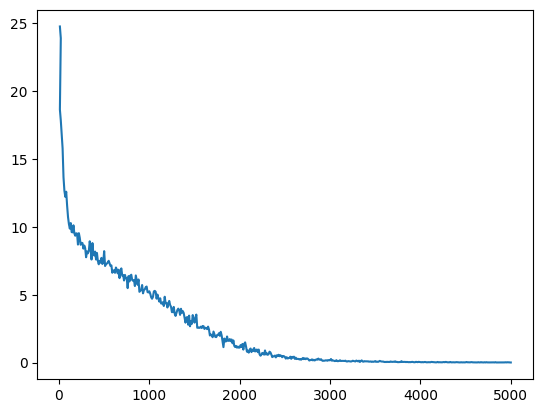

In [42]:
plt.figure()
plt.plot(train_loss['step'],train_loss['loss'])

In [27]:
df = pd.read_csv('train_data_4_long.csv')

In [28]:
urls = df['image url'].unique()


In [32]:
import random

In [34]:
test_urls = random.sample(urls.tolist(),20)

In [35]:
test_data = df[df['image url'].isin(test_urls)]

In [37]:
test_data.to_csv('test_data_long.csv')

In [38]:
train_data = df[~df['image url'].isin(test_urls)]

In [39]:
len(train_data)

1656

In [40]:
train_data.to_csv('train_data_long.csv')